In [87]:
import torch

In [88]:
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(torch.cuda.get_device_properties(i).name)
else:
    print('GPU not available!')

NVIDIA GeForce RTX 3060 Laptop GPU


In [89]:
import json
import pathlib

data = {'orders': []}
seen_ids = set()

for fname in pathlib.Path('../data/saved_rivens').iterdir():
    if "syam" in fname.stem:
        with open(fname) as file:
            orders = json.load(file)
            for order in orders['orders']:
                order_id = order['id']
                if not order_id in seen_ids:
                    seen_ids.add(order_id)
                    data['orders'].append(order)
    
print(data['orders'][0])
print(f'Number of orders: {len(seen_ids)}')

{'id': '6831c2ac50c779002b6bd58f', 'type': 'sell', 'user': {'status': 'offline'}, 'item': {'re_rolls': 33, 'type': 'riven', 'mod_rank': 8, 'polarity': 'vazarin', 'mastery_level': 12, 'weapon_url_name': 'syam', 'name': 'acri-critaum', 'attributes': [{'value': 15.9, 'positive': True, 'url_name': 'channeling_damage'}, {'value': 68.6, 'positive': True, 'url_name': 'critical_damage'}, {'value': 133.2, 'positive': True, 'url_name': 'critical_chance'}, {'value': -68.8, 'positive': False, 'url_name': 'puncture_damage'}]}, 'platinum': 888888}
Number of orders: 459


In [93]:
orders = data['orders']
attributes_list = [order['item']['attributes'] for order in orders]
flatten_attributes = [attribute for attribute_list in attributes_list for attribute in attribute_list]
attribute_names = {attribute['url_name'] for attribute in flatten_attributes}

other_item_attributes = {'re_rolls', 'mod_rank'}

print(attribute_names)
with open('../data/attributes.json', 'w') as file:
    json.dump([attribute for attribute in attribute_names], file)
print(other_item_attributes)

x_attributes = attribute_names.copy()
x_attributes.update(other_item_attributes)
print(x_attributes)

{'damage_vs_grineer', 'slash_damage', 'heat_damage', 'critical_chance_on_slide_attack', 'channeling_efficiency', 'critical_damage', 'range', 'cold_damage', 'electric_damage', 'critical_chance', 'status_duration', 'toxin_damage', 'punch_through', 'fire_rate_/_attack_speed', 'channeling_damage', 'chance_to_gain_combo_count', 'status_chance', 'damage_vs_infested', 'puncture_damage', 'chance_to_gain_extra_combo_count', 'combo_duration', 'base_damage_/_melee_damage', 'damage_vs_corpus', 'finisher_damage'}
{'re_rolls', 'mod_rank'}
{'damage_vs_infested', 'mod_rank', 'channeling_damage', 'damage_vs_grineer', 'slash_damage', 'heat_damage', 'puncture_damage', 'critical_chance_on_slide_attack', 'chance_to_gain_extra_combo_count', 'channeling_efficiency', 'critical_damage', 'range', 'combo_duration', 'cold_damage', 'electric_damage', 'base_damage_/_melee_damage', 'critical_chance', 'status_duration', 'toxin_damage', 'damage_vs_corpus', 'finisher_damage', 're_rolls', 'punch_through', 'fire_rate_/_a

In [100]:
import numpy as np

def parse_order(order):
    item = order['item']
    item_attributes = {attribute['url_name']: attribute['value'] for attribute in item['attributes']}

    price = order['platinum']
    attribute_values = []
    for attribute_name in attribute_names:
        attr_value = np.int64(item_attributes.get(attribute_name) or 0)
        attribute_values.append(attr_value)
        attribute_values.append(np.sign(attr_value))

    for attribute_name in other_item_attributes:
        attribute_values.append(np.int64(item.get(attribute_name) or 0))
    
    return attribute_values, price

In [101]:
x_attributes, _ = parse_order(orders[0])
number_of_attributes = len(x_attributes)
print(x_attributes)
print(number_of_attributes)

[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(68), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(133), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(15), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(-68), np.int64(-1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(33), np.int64(8)]
50


In [102]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [104]:
X = [parse_order(order)[0] for order in orders]
y = [parse_order(order)[1] for order in orders]

print(X)
print(y)

print(f'[Sanity Check] Number of plat prices matches number of rivens: {len(X) == len(y)}')

[[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(68), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(133), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(15), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(-68), np.int64(-1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(33), np.int64(8)], [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(63), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0),

from torch.utils.data import Dataset


class RivenDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [128]:
from torch import nn


class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.hidden_layer1 = nn.Linear(number_of_attributes, 128)
        self.hidden_layer2 = nn.Linear(128, 128)
        self.hidden_layer3 = nn.Linear(128, 64)
        self.hidden_layer4 = nn.Linear(64, 32)
        self.hidden_layer5 = nn.Linear(32, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.hidden_layer1(x))
        x = torch.relu(self.hidden_layer2(x))
        x = torch.relu(self.hidden_layer3(x))
        x = torch.relu(self.hidden_layer4(x))
        x = torch.relu(self.hidden_layer5(x))
        x = self.output(x)
        return x.squeeze(-1)

In [129]:
import random

def split_data(x, y, ratio=0.5, seed=2):
    assert len(x) == len(y)
    split_index = int(len(x) * ratio)

    x_shuffle = x.copy()
    random.Random(seed).shuffle(x_shuffle)

    y_shuffle = y.copy()
    random.Random(seed).shuffle(y_shuffle)

    return x_shuffle[:split_index], x_shuffle[split_index:], y_shuffle[:split_index], y_shuffle[split_index:]

In [130]:
from torch.utils.data import DataLoader, random_split, TensorDataset

X_train, X_test, y_train, y_test = split_data(X, y, 0.5)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

# dataset = TensorDataset(X_tensor, y_tensor)
#
# training_data, test_data = random_split(dataset, [0.8, 0.2])
#
# train_dataloader = DataLoader(training_data, shuffle=True)
# test_dataloader = DataLoader(test_data, shuffle=True)

In [131]:
from torch import optim

model = NeuralNetwork().to(device)
print(model)

loss_function = nn.MSELoss(reduction='none').to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

NeuralNetwork(
  (hidden_layer1): Linear(in_features=50, out_features=128, bias=True)
  (hidden_layer2): Linear(in_features=128, out_features=128, bias=True)
  (hidden_layer3): Linear(in_features=128, out_features=64, bias=True)
  (hidden_layer4): Linear(in_features=64, out_features=32, bias=True)
  (hidden_layer5): Linear(in_features=32, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)


In [132]:
num_epochs = 600
epoch = 0

loss_values = []

for epoch in range(num_epochs):
    model.train()
    y_pred = model(X_train_tensor)
    loss = loss_function(y_pred, y_train_tensor)

    optimizer.zero_grad()
    loss.mean().backward()
    optimizer.step()

    train_loss = loss.mean().item()
    loss_values.append(train_loss)

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor)
        loss = loss_function(y_pred, y_test_tensor)
        test_loss = loss.mean().item()

    print(f'[Epoch {epoch}] Train MSE: {train_loss:.4f} Test MSE: {test_loss:.4f}')


[Epoch 0] Train MSE: 5608638.5000 Test MSE: 3438560768.0000
[Epoch 1] Train MSE: 5608330.0000 Test MSE: 3438560000.0000
[Epoch 2] Train MSE: 5608210.5000 Test MSE: 3438559232.0000
[Epoch 3] Train MSE: 5608074.5000 Test MSE: 3438557952.0000
[Epoch 4] Train MSE: 5607890.5000 Test MSE: 3438556928.0000
[Epoch 5] Train MSE: 5607655.0000 Test MSE: 3438554880.0000
[Epoch 6] Train MSE: 5607380.0000 Test MSE: 3438553344.0000
[Epoch 7] Train MSE: 5607067.5000 Test MSE: 3438551552.0000
[Epoch 8] Train MSE: 5606704.0000 Test MSE: 3438549504.0000
[Epoch 9] Train MSE: 5606263.5000 Test MSE: 3438546944.0000
[Epoch 10] Train MSE: 5605724.0000 Test MSE: 3438543360.0000
[Epoch 11] Train MSE: 5605069.0000 Test MSE: 3438539008.0000
[Epoch 12] Train MSE: 5604275.0000 Test MSE: 3438534144.0000
[Epoch 13] Train MSE: 5603317.5000 Test MSE: 3438528256.0000
[Epoch 14] Train MSE: 5602161.5000 Test MSE: 3438520576.0000
[Epoch 15] Train MSE: 5600773.5000 Test MSE: 3438511360.0000
[Epoch 16] Train MSE: 5599107.5000

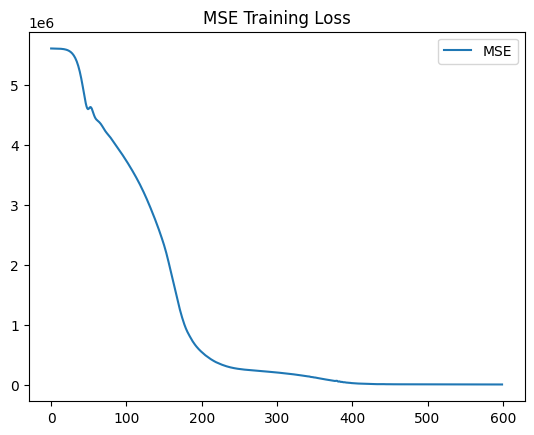

In [133]:
import matplotlib.pyplot as plt

plt.plot(loss_values, label='MSE')
plt.legend()
plt.title('MSE Training Loss')
plt.show()

In [134]:
y_train = []
y_train_pred = []

model.eval()
with torch.no_grad():
    y_pred = model(X_train_tensor)
    loss = loss_function(y_pred, y_train_tensor)

    y_train.extend([y.item() for y in y_train_tensor])
    y_train_pred.extend([y.item() for y in y_pred])

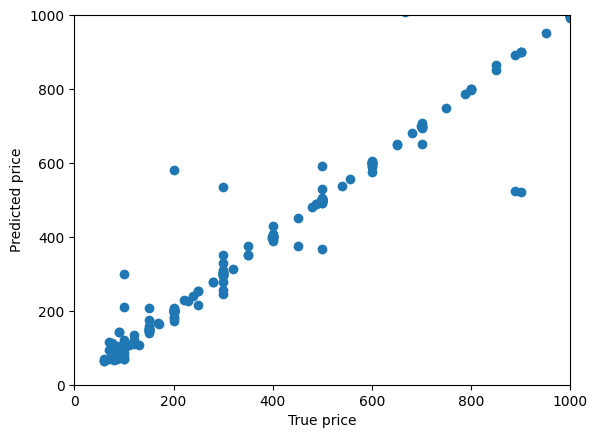

In [135]:
lim = [0, 1e3]

plt.scatter(y_train, y_train_pred)
plt.xlabel('True price')
plt.ylabel('Predicted price')
plt.xlim(lim)
plt.ylim(lim)
plt.show()

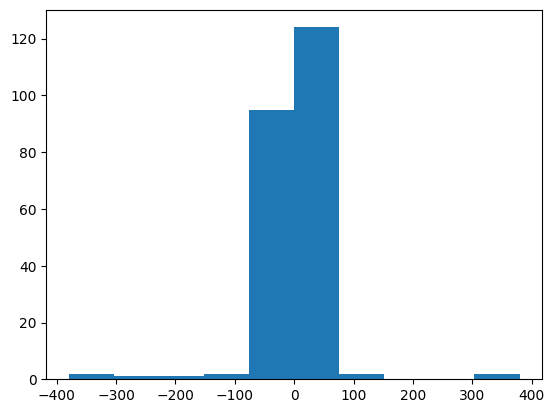

In [136]:
residuals = [y_true - y_pred for y_true, y_pred in zip(y_train, y_train_pred)]

plt.hist(residuals)
plt.show()

In [137]:
y_test = []
y_test_pred = []

model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    loss = loss_function(y_pred, y_test_tensor)

    y_test.extend([y.item() for y in y_test_tensor])
    y_test_pred.extend([y.item() for y in y_pred])

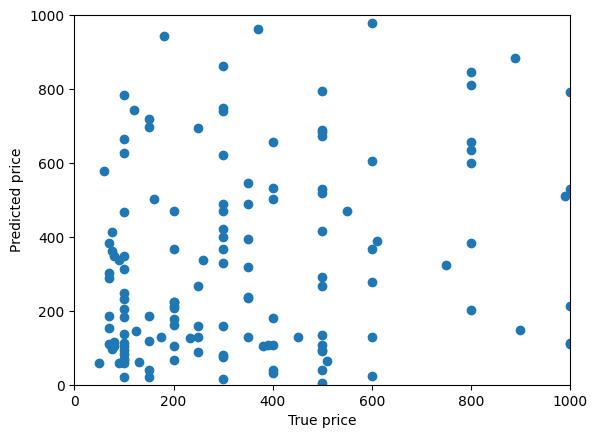

In [138]:
lim = [0, 1e3]

plt.scatter(y_test, y_test_pred)
plt.xlabel('True price')
plt.ylabel('Predicted price')
plt.xlim(lim)
plt.ylim(lim)
plt.show()

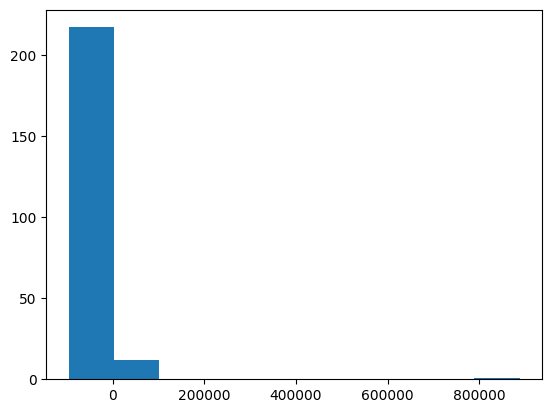

In [139]:
residuals = [y_true - y_pred for y_true, y_pred in zip(y_test, y_test_pred)]

plt.hist(residuals)
plt.show()

In [551]:
import pathlib

model_save_path = pathlib.Path('../data/model.dat')
torch.save(model, model_save_path)

model = NeuralNetwork()
model.load_state_dict(model_save_path)

TypeError: Expected state_dict to be dict-like, got <class 'pathlib._local.PosixPath'>.